In [1]:
'''
from google.colab import drive
drive.mount('/content/drive')
'''

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [2]:
%pip install gradio
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Block 1

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
import torch.nn.functional as F
import shutil
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from scipy.ndimage import distance_transform_edt
import cv2
import gradio as gr
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imsave
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from scipy.ndimage import distance_transform_edt
import cv2


Home Page

In [4]:
# Block 2

import gradio as gr

def home_page():
    return gr.Markdown(
        """
        # Cell Segmentor Dashboard
        Welcome to the **Cell Segmentor Dashboard**. This dashboard leverages the power of a U-Net++ model for cell nuclei segmentation, refined through a custom-designed pipeline for image analysis. Built specifically for microscopy imaging in cell research, this tool aids in precise identification and separation of individual nuclei, even in densely packed cellular structures.

        ### Key Features
        - **Automated Nuclei Segmentation**: Upload a microscopy image, and the dashboard will automatically apply the U-Net++ model to detect and segment cell nuclei with high precision.
        - **Refined Separation of Overlapping Nuclei**: Using watershed and distance transform methods, overlapping nuclei are carefully separated for individual analysis.
        - **Interactive Nuclei Properties**: After segmentation, each nucleus is assigned a unique label, and users can explore detailed properties, including area, perimeter, compactness, eccentricity, solidity, and orientation.
        - **Manual Drawing and Property Calculation**: For customized analysis, use the sketchpad tool to draw shapes on a transparent layer over an uploaded image and calculate shape properties.

        ### Data and Training
        - The segmentation model was trained on preprocessed microscopy images and labels from the **Data Science Bowl 2018** dataset, which provides robust, realistic examples of cellular structures.
        - The dataset was split into training, validation, and test sets to ensure model generalization and accuracy across unseen data.

        ### How to Use the Dashboard
        - **Application**: Navigate to the **Segment Cells** tab to start with automated segmentation or to manually draw and analyze shapes.
        - **About**: Visit this section to learn more about the underlying techniques and intended use cases.

        ### Navigation
        - **Segment Cells**: Begin your segmentation task by uploading an image for automated analysis.
        - **Draw and Calculate Shape Properties**: Customize the analysis by drawing regions on an image for specific property calculations.

        ### Acknowledgments
        This tool was developed using U-Net++ architecture and leverages advanced image processing techniques to support scientific research in cellular biology. It is especially suited for applications in cell structure analysis, allowing for accurate morphological insights.

        """
    )

# Create the home page layout
home_interface = gr.Interface(
    fn=home_page,
    inputs=[],
    outputs="markdown",
    title="Cell Segmentor Dashboard - Home"
)

home_interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://ba7e867b4017329448.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Application Page

In [ ]:
# Block 3

import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imsave
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from skimage.morphology import h_maxima
from scipy.ndimage import distance_transform_edt, binary_fill_holes
import cv2
import io
from PIL import Image
from pathlib import Path
import csv


from skimage.filters import threshold_otsu                                                                              # $ hier
from skimage.morphology import remove_small_objects, remove_small_holes, opening, closing, disk
from skimage.feature import peak_local_max




# Define U-Net++ model architecture
class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetPlusPlus, self).__init__()

        # Encoder path
        self.encoder1 = self.double_conv(in_channels, 64)
        self.encoder2 = self.double_conv(64, 128)
        self.encoder3 = self.double_conv(128, 256)
        self.encoder4 = self.double_conv(256, 512)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)

        # Decoder path with nested convolutions (UNet++)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4_1 = self.double_conv(1024, 512)
        self.decoder4_2 = self.double_conv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3_1 = self.double_conv(512, 256)
        self.decoder3_2 = self.double_conv(512, 256)
        self.decoder3_3 = self.double_conv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2_1 = self.double_conv(256, 128)
        self.decoder2_2 = self.double_conv(256, 128)
        self.decoder2_3 = self.double_conv(256, 128)
        self.decoder2_4 = self.double_conv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1_1 = self.double_conv(128, 64)
        self.decoder1_2 = self.double_conv(128, 64)
        self.decoder1_3 = self.double_conv(128, 64)
        self.decoder1_4 = self.double_conv(128, 64)
        self.decoder1_5 = self.double_conv(128, 64)

        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels, dropout_prob=0.1):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ELU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ELU(inplace=True),
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(F.max_pool2d(e1, 2))
        e3 = self.encoder3(F.max_pool2d(e2, 2))
        e4 = self.encoder4(F.max_pool2d(e3, 2))

        b = self.bottleneck(F.max_pool2d(e4, 2))

        d4_1 = self.upconv4(b)
        d4_1 = torch.cat([d4_1, e4], dim=1)
        d4_1 = self.decoder4_1(d4_1)

        d3_1 = self.upconv3(d4_1)
        d3_1 = torch.cat([d3_1, e3], dim=1)
        d3_1 = self.decoder3_1(d3_1)

        d2_1 = self.upconv2(d3_1)
        d2_1 = torch.cat([d2_1, e2], dim=1)
        d2_1 = self.decoder2_1(d2_1)

        d1_1 = self.upconv1(d2_1)
        d1_1 = torch.cat([d1_1, e1], dim=1)
        d1_1 = self.decoder1_1(d1_1)

        out = torch.sigmoid(self.out_conv(d1_1))
        out = F.interpolate(out, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        return out

# Load the pre-trained model weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(in_channels=3, out_channels=1).to(device)

model_path = Path.cwd().parent / 'CellSeg_Extension' / 'results' / 'saved_models' / 'unet++_model.pth'


model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


########################################################################################################################
with open(Path('./image_preprocessing/image_data.csv'), newline='') as f:
    reader = csv.DictReader(f)
    row = next(reader)
    img_size = int(row['img_size'])


def prep_image_for_model(image, image_size=img_size):
    height, width  = image.shape[:2]
    image          = image.astype(np.float32) / 255.0
    image_resized  = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    image_tensor   = torch.from_numpy(image_resized.transpose(2,0,1)).unsqueeze(0).float().to(device)

    return image_tensor, (height, width)


def segment_cells(image, min_peak_dist=1):

    
    image_tensor, (height, width) = prep_image_for_model(image)

    with torch.no_grad():
        prob_resized  = torch.sigmoid(model(image_tensor)).squeeze().cpu().numpy()
    prob_original_img = cv2.resize(prob_resized, (width, height), interpolation=cv2.INTER_CUBIC)

    tmp_th = threshold_otsu(prob_original_img)
    binary = prob_original_img > tmp_th
    filled_mask = binary_fill_holes(binary).astype(np.uint8)

    # watershed
    # h_maxima might not be dynamic enough, therefore:
    dist_map = distance_transform_edt(filled_mask)
    coords   = peak_local_max(dist_map, labels=binary, footprint=np.ones((10,10), np.uint8), min_distance=min_peak_dist) # footprint and min_distance are important for nuclei detection, change here, if primarily the numbers aren't to your liking
    markers  = np.zeros_like(dist_map, dtype=np.int32)
    if len(coords) > 0:
        markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    labels   = watershed(-dist_map, markers=markers, mask=binary)



    ''' 
    # can be used for a second segmentation step, but for me it did nothing extra and could potentially be too static
    # with the hard set h=0.3 Haven't tested it though.
    
    # Refine segmentation for overlapping nuclei
    labels_ord = np.zeros_like(labels)
    current_label = 1

    for region in regionprops(labels):
        nucleus_mask = (labels == region.label)
        distance_local = distance_transform_edt(nucleus_mask)
        local_h_maxima = h_maxima(distance_local, h=0.3 * distance_local.max())
        local_markers = label(local_h_maxima)
        refined_labels = watershed(-distance_local, local_markers, mask=nucleus_mask)
        refined_labels[refined_labels > 0] += current_label - 1
        labels_ord += refined_labels
        current_label = labels_ord.max() + 1
    '''

    # sort masks to color them from top to bottom - not random; not necessary but visually more pleasing                (it's only necessary when not using h_maxima)
    rainbow = False
    if rainbow:
        region = regionprops(labels)
        order  = sorted(((r.label, r.centroid[0]) for r in region), key=lambda t: t[1])
        remap  = {old_label: i+1 for i, (old_label, _) in enumerate(order)}

        labels_ord = np.zeros_like(labels, dtype=labels.dtype)

        for old_lab, new_lab in remap.items():
            labels_ord[labels == old_lab] = new_lab
    else:
        labels_ord = labels
    
    # Visualization
    fig_colored, ax = plt.subplots(figsize=(6,6))
    ax.imshow(labels_ord, cmap='nipy_spectral')
    ax.axis('off')
    plt.close(fig_colored)

    fig_numbered, ax = plt.subplots(figsize=(6,6))
    ax.imshow(filled_mask, cmap='gray')
    for region in regionprops(labels_ord):
        y, x = region.centroid
        ax.text(x, y, f'{region.label}', color='red', fontsize=10, ha='center')
    ax.axis('off')
    plt.close(fig_numbered)

    # Calculating properties of refined labeled regions
    properties = []
    for region in regionprops(labels_ord):
        area  = region.area
        perimeter = region.perimeter
        compactness = (4 * np.pi * area)/(perimeter ** 2) if perimeter > 0 else 0
        properties.append({
            "area": area,
            "perimeter": perimeter,
            "compactness": compactness,
            "eccentricity": region.eccentricity,
            "solidity": region.solidity,
            "major_axis_length": region.major_axis_length,
            "minor_axis_length": region.minor_axis_length,
            "aspect_ratio": region.major_axis_length / region.minor_axis_length if region.minor_axis_length > 0 else 0,
            "orientation": region.orientation,
        })

    individual_masks = [(labels_ord == i).astype(np.uint8) * 255 for i in range(1, labels_ord.max() + 1)]               # Gallery of masks
    return fig_colored, fig_numbered, individual_masks, properties



########################################################################################################################











'''                                                                                                                     legacy
# Function for refined cell segmentation
def segment_cells(image):
    image_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(device)
    with torch.no_grad():
        predicted_mask = torch.sigmoid(model(image_tensor)).squeeze().cpu().numpy() > 0.5

    # Fill holes in the binary mask
    filled_mask = binary_fill_holes(predicted_mask).astype(np.uint8)

    # Compute the distance transform
    distance_map = distance_transform_edt(filled_mask)

    # Detect peaks using H-maxima transform
    h_maxima_markers = h_maxima(distance_map, h=0.1 * distance_map.max())
    markers = label(h_maxima_markers)

    # Apply watershed segmentation
    initial_labels = watershed(-distance_map, markers, mask=filled_mask)

    # Refine segmentation for overlapping nuclei
    final_labels = np.zeros_like(initial_labels)
    current_label = 1

    for region in regionprops(initial_labels):
        nucleus_mask = (initial_labels == region.label)
        distance_local = distance_transform_edt(nucleus_mask)
        local_h_maxima = h_maxima(distance_local, h=0.3 * distance_local.max())
        local_markers = label(local_h_maxima)
        refined_labels = watershed(-distance_local, local_markers, mask=nucleus_mask)
        refined_labels[refined_labels > 0] += current_label - 1
        final_labels += refined_labels
        current_label = final_labels.max() + 1

    # Visualization of refined segmentation (color mask only)
    fig_colored, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(final_labels, cmap='nipy_spectral')
    ax.axis('off')
    plt.close(fig_colored)

    # Visualization of numbered binary mask
    fig_numbered, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(filled_mask, cmap='gray')
    for region in regionprops(final_labels):
        y, x = region.centroid
        ax.text(x, y, f'{region.label}', color='red', fontsize=12, ha='center')
    ax.axis('off')
    plt.close(fig_numbered)

    # Calculating properties of refined labeled regions
    properties = []
    for region in regionprops(final_labels):
        # Compute additional properties for each nucleus
        area = region.area
        perimeter = region.perimeter
        compactness = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        eccentricity = region.eccentricity
        solidity = region.solidity
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length
        aspect_ratio = major_axis_length / minor_axis_length if minor_axis_length > 0 else 0
        orientation = region.orientation

        # Add computed properties to the properties list
        properties.append({
            "area": area,
            "perimeter": perimeter,
            "compactness": compactness,
            "eccentricity": eccentricity,
            "solidity": solidity,
            "major_axis_length": major_axis_length,
            "minor_axis_length": minor_axis_length,
            "aspect_ratio": aspect_ratio,
            "orientation": orientation,
        })

    # Generate individual masks for gallery
    individual_masks = [(final_labels == i).astype(np.uint8) * 255 for i in range(1, final_labels.max() + 1)]

    return fig_colored, fig_numbered, individual_masks, properties

'''


# Function to fetch properties of a selected nucleus
def get_nucleus_properties(index, properties):
    if 0 <= index < len(properties):
        selected_props = properties[index]
        return (
            f"Area: {selected_props['area']} pixels\n"
            f"Perimeter: {selected_props['perimeter']:.2f} pixels\n"
            f"Compactness: {selected_props['compactness']:.2f}\n"
            f"Eccentricity: {selected_props['eccentricity']:.2f}\n"
            f"Solidity: {selected_props['solidity']:.2f}\n"
            f"Major Axis Length: {selected_props['major_axis_length']:.2f} pixels\n"
            f"Minor Axis Length: {selected_props['minor_axis_length']:.2f} pixels\n"
            f"Aspect Ratio: {selected_props['aspect_ratio']:.2f}\n"
            f"Orientation: {selected_props['orientation']:.2f} radians"
        )
    else:
        return "Select a nucleus to view its properties."

# New function for drawing on an image and calculating shape properties
def create_filled_binary_mask_and_calculate_properties(drawn_shape):
    debug_output = io.StringIO()
    try:
        if isinstance(drawn_shape, dict) and 'layers' in drawn_shape:
            drawn_shape = drawn_shape['layers']

        if drawn_shape is None:
            raise ValueError("No drawing layer found in the dictionary returned by Sketchpad")

        if not isinstance(drawn_shape, np.ndarray):
            drawn_shape = np.array(drawn_shape, dtype=np.uint8)

        if drawn_shape.ndim == 4 and drawn_shape.shape[0] == 1:
            drawn_shape = np.squeeze(drawn_shape, axis=0)

        if drawn_shape.ndim == 3 and drawn_shape.shape[2] == 4:
            alpha_channel = drawn_shape[:, :, 3]
            mask = alpha_channel > 0
            gray_image = np.where(mask, 255, 0).astype(np.uint8)
        elif drawn_shape.ndim == 3:
            gray_image = cv2.cvtColor(drawn_shape, cv2.COLOR_RGB2GRAY)
        else:
            gray_image = drawn_shape

        _, binary_mask = cv2.threshold(gray_image, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        filled_mask = np.zeros_like(binary_mask)
        cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)

        if not contours:
            return filled_mask, "No contours found."

        contour = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        compactness = (perimeter**2) / (4 * np.pi * area) if area > 0 else 0

        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0

        if len(contour) >= 5:
            ellipse = cv2.fitEllipse(contour)
            (center, axes, angle) = ellipse
            major_axis_length = max(axes)
            minor_axis_length = min(axes)
            aspect_ratio = major_axis_length / minor_axis_length if minor_axis_length > 0 else 0
            orientation = np.deg2rad(angle)
            eccentricity = np.sqrt(1 - (minor_axis_length / major_axis_length)**2)
        else:
            major_axis_length = minor_axis_length = aspect_ratio = orientation = eccentricity = 0

        properties_text = (
            f"Area: {area} pixels\n"
            f"Perimeter: {perimeter:.2f} pixels\n"
            f"Compactness: {compactness:.2f}\n"
            f"Eccentricity: {eccentricity:.2f}\n"
            f"Solidity: {solidity:.2f}\n"
            f"Major Axis Length: {major_axis_length:.2f}\n"
            f"Minor Axis Length: {minor_axis_length:.2f}\n"
            f"Aspect Ratio: {aspect_ratio:.2f}\n"
            f"Orientation: {orientation:.2f} radians"
        )

        return filled_mask, properties_text
    except Exception as e:
        return np.zeros((512, 512), dtype=np.uint8), f"Error: {e}"

'''
# Gradio Interface for Segmenting Cells
application_interface = gr.Interface(
    fn=segment_cells,
    inputs=gr.Image(label="Upload an Image", type="numpy"),
    outputs=[
        gr.Plot(label="Refined Segmentation Mask"),
        gr.Plot(label="Numbered Nuclei Mask"),
        gr.Gallery(label="Individual Nuclei Masks", interactive=True),
        gr.Textbox(label="Nucleus Properties", placeholder="Select a nucleus to view its properties")
    ],
    title="Cell Segmentor Dashboard - Application",
    description="Upload an image of cells. The model will segment the nuclei with refined watershed-based separation for overlapping objects, and label each nucleus with a unique number.",
)
'''
with gr.Blocks() as application_interface:
    gr.Markdown("# Cell Segmentation with U-Net++ and Refined Post-Processing")

    with gr.Row():
        input_image = gr.Image(label="Upload an Image", type="numpy")

    with gr.Row():
        segmented_colored = gr.Plot(label="Refined Segmentation Mask")
        segmented_numbered = gr.Plot(label="Numbered Binary Mask")

    individual_nuclei = gr.Gallery(label="Individual Nuclei Masks", interactive=True)
    nucleus_properties = gr.Textbox(label="Nucleus Properties", value="Select a nucleus to view its properties.")

    # Store properties as a state variable
    properties_state = gr.State()

    # Load image and perform segmentation
    def on_segment(image):
        fig_colored, fig_numbered, individual_masks, properties = segment_cells(image)
        return fig_colored, fig_numbered, individual_masks, properties

    # Fetch properties when an image is selected
    def on_select_image(evt: gr.SelectData, properties):
        selected_index = evt.index
        return get_nucleus_properties(selected_index, properties)

    # Connect functions to components

    input_image.upload(on_segment, inputs=input_image, outputs=[segmented_colored, segmented_numbered, individual_nuclei, properties_state])

    individual_nuclei.select(on_select_image, inputs=properties_state, outputs=nucleus_properties)

# Gradio Interface for Drawing on Image and Calculating Shape Properties
with gr.Blocks() as manual_separation_interface:
    gr.Markdown("## Upload an Image as Background, Draw on Transparent Layer, and Calculate Shape Properties")

    background_image_input = gr.Image(type="pil", label="Upload Background Image")
    drawn_shape_input = gr.Sketchpad(label="Draw on Layer", type="pil")

    filled_shape_output = gr.Image(label="Filled Shape")
    debug_output = gr.Textbox(label="Shape Properties and Debugging Output")

    generate_button = gr.Button("Generate segmented nucleus and relevant dimensions")
    generate_button.click(fn=create_filled_binary_mask_and_calculate_properties, inputs=[drawn_shape_input], outputs=[filled_shape_output, debug_output])

    background_image_input.change(fn=lambda img: img.convert("RGBA"), inputs=[background_image_input], outputs=[drawn_shape_input])

# Combine both interfaces into a tabbed interface
app_interface = gr.TabbedInterface([application_interface, manual_separation_interface], ["Automatic Segmentation", "Manual Segmentation"])
app_interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://93c99265a7628946a0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


--------------------------------------------------

---



---



# Evaluation

In [16]:
import os, glob, cv2, pandas as pd, numpy as np, torch
from tqdm import tqdm
import numpy as np
from skimage.filters import threshold_otsu


img_dir = Path('./image_preprocessing/preprocessed_data/preprocessed_test_images')
gt_dir  = Path('./image_preprocessing/preprocessed_data/preprocessed_test_masks')
out_csv = Path('val_thresholding_comparison.csv')
fixed_thr = 0.5


def dice_coefficient(logits, targets, smooth=1.0):
    """
    It's the same function as before, I just adjusted the names to be consistent with the other changes and changed
    the dim to [1,2,3] as we have shape [B, C, H, W] we need to sum over C, H and W.

    The dice coefficient (or Sørensen-Dice index) meassures the similarity between two datasets. It's formular is:

        Dice Coefficient = 2 * |X ∩ Y| / |X| + |Y|
    
        with X and Y being the sets of pixels in those images. In other words, the formular can be written like:
        
        Dice Coefficient = 2 * Area of Overlap / Total Number of Pixels in Both Segmentations

    """
    p = (torch.sigmoid(logits) > 0.5).float()
    targets = targets.float()
    intersection = (p * targets).sum(dim=[1,2,3])
    return ((2 * intersection + smooth) / (p.sum(dim=[1,2,3]) + targets.sum(dim=[1,2,3]) + smooth)).mean()


def binarize(prob_map, mode='otsu'):
    if mode == 'fixed':
        thr = float(fixed_thr)
    elif mode == "otsu":
        thr = float(threshold_otsu(prob_map))
    return (prob_map > thr).astype(np.uint8), thr


def predict_prob_map(model, x, orig_hw):
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.sigmoid(logits)[0,0].cpu().numpy()
    H, W = orig_hw
    return cv2.resize(probs, (W, H), interpolation=cv2.INTER_CUBIC)


def to_tensor(img_bgr, image_size=img_size):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_rsz = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA)
    array   = np.transpose(img_rsz, (2,0,1))[None, ...]  # [1,3,H,W]
    return torch.from_numpy(array).float().to(device)


def list_images(root, image_datatypes=('*.png','*.jpg','*.jpeg')):
    paths = []
    for e in image_datatypes:
        paths.extend(glob.glob(os.path.join(root, e)))
    return sorted(paths)


img_paths = list_images(img_dir)
if not img_paths:
    raise FileNotFoundError(f'Keine Bilder in {img_dir} gefunden.')

rows = []
missing_gt = []
processed = 0

model.eval()
for p in tqdm(img_paths, desc='Eval', unit='img'):
    base = os.path.basename(p)
    gt_p = os.path.join(gt_dir, base)

    gt = cv2.imread(gt_p, cv2.IMREAD_GRAYSCALE)
    if gt is None:
        missing_gt.append(base)
        continue
    gt_bin = (gt > 0).astype(np.uint8)

    img = cv2.imread(p, cv2.IMREAD_COLOR)
    if img is None:
        continue

    x = to_tensor(img)
    prob_map = predict_prob_map(model, x, (img.shape[0], img.shape[1]))

    mask_fix, thr_fix = binarize(prob_map, mode='fixed')
    mask_ots, thr_ots = binarize(prob_map, mode='otsu')

    t_fix = torch.from_numpy(mask_fix[None, None]).float().to(device)
    t_ots = torch.from_numpy(mask_ots[None, None]).float().to(device)
    t_gt  = torch.from_numpy(gt_bin[None, None]).float().to(device)

    dice_fixed = float(dice_coefficient(t_fix, t_gt).cpu())
    dice_otsu  = float(dice_coefficient(t_ots, t_gt).cpu())

    rows.append({
        'image': base,
        'thr_otsu':   round(float(thr_ots), 3),
        'dice_otsu':  round(dice_otsu, 4),
        'thr_fixed':  round(float(thr_fix), 3),
        'dice_fixed': round(dice_fixed, 4)
    })
    processed += 1

cols = ['image','thr_otsu','dice_otsu','thr_fixed','dice_fixed']
df = pd.DataFrame(rows, columns=cols)
df.to_csv(out_csv, index=False)

if processed == 0:
    print("No samples processed.")
else:
    mean_fixed = float(df['dice_fixed'].mean())
    mean_otsu  = float(df['dice_otsu'].mean())
    std_fixed  = float(df['dice_fixed'].std())
    std_otsu   = float(df['dice_otsu'].std())

    print('Saved CSV: ', out_csv)
    print('Processed: ', processed)
    print(f'Mean Dice (fixed): {mean_fixed:.4f} ± {std_fixed:.4f}')
    print(f'Mean Dice (Otsu):  {mean_otsu:.4f} ± {std_otsu:.4f}')


Eval: 100%|██████████| 100/100 [00:02<00:00, 43.36img/s]

Saved CSV:  val_thresholding_comparison.csv
Processed:  100
Mean Dice (fixed): 0.2705 ± 0.1120
Mean Dice (Otsu):  0.8035 ± 0.1049


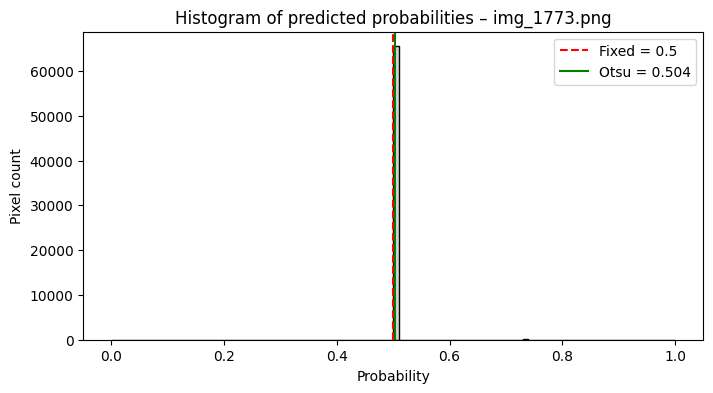

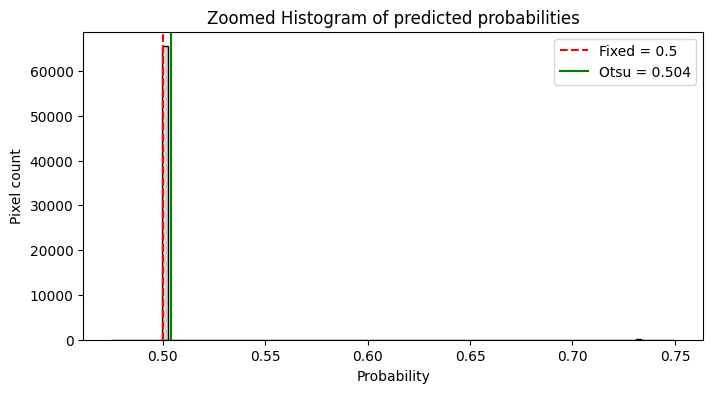

Fixed threshold: 0.500 | FG pixels: 21676
Otsu  threshold: 0.504 | FG pixels: 56
Dice (fixed): 0.0057
Dice (Otsu):  0.9576


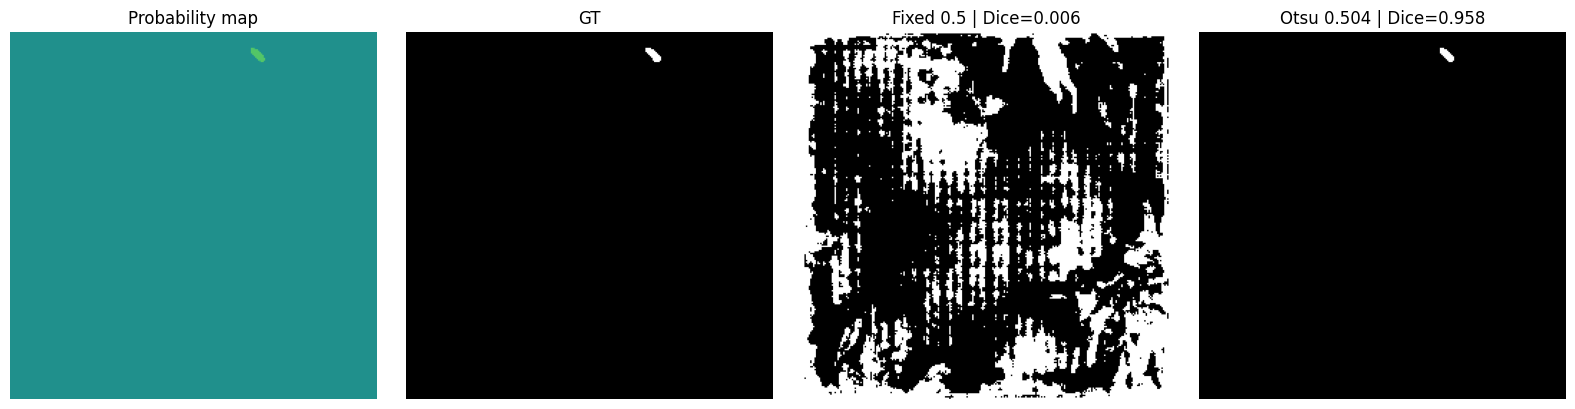

In [24]:
import os, cv2, numpy as np, torch, matplotlib.pyplot as plt
%matplotlib inline


filename = 'img_1773.png'
img_path = str(img_dir / filename)
gt_path  = str(gt_dir / filename)

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
H, W = img.shape[:2]

gt = None
if os.path.exists(gt_path):
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    if gt is not None:
        gt = (gt > 0).astype(np.uint8)

model.eval()
with torch.no_grad():
    x = to_tensor(img)
    prob_map = predict_prob_map(model, x, (H, W))

mask_fix, thr_fix = binarize(prob_map, mode='fixed')
mask_ots, thr_ots = binarize(prob_map, mode='otsu')

dice_fix = dice_ots = None
if gt is not None:
    t_fix = torch.from_numpy(mask_fix[None, None]).float().to(device)
    t_ots = torch.from_numpy(mask_ots[None, None]).float().to(device)
    t_gt  = torch.from_numpy(gt[None, None]).float().to(device)
    dice_fix = float(dice_coefficient(t_fix, t_gt).cpu())
    dice_ots = float(dice_coefficient(t_ots, t_gt).cpu())

plt.figure(figsize=(8,4))
plt.hist(prob_map.flatten(), bins=100, range=(0,1), color='lightgray', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Fixed = 0.5')
plt.axvline(thr_ots, color='green', linestyle='-', label=f'Otsu = {thr_ots:.3f}')
plt.title(f'Histogram of predicted probabilities – {filename}')
plt.xlabel('Probability'); plt.ylabel('Pixel count'); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.hist(prob_map.flatten(), bins=100, range=(0.475,0.75), color='lightgray', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Fixed = 0.5')
plt.axvline(thr_ots, color='green', linestyle='-', label=f'Otsu = {thr_ots:.3f}')
plt.title('Zoomed Histogram of predicted probabilities')
plt.xlabel('Probability')
plt.ylabel('Pixel count')
plt.legend()
plt.show()

fg_fix = int((prob_map > 0.5).sum())
fg_ots = int((prob_map > thr_ots).sum())
print(f'Fixed threshold: 0.500 | FG pixels: {fg_fix}')
print(f'Otsu  threshold: {thr_ots:.3f} | FG pixels: {fg_ots}')
if dice_fix is not None:
    print(f'Dice (fixed): {dice_fix:.4f}')
    print(f'Dice (Otsu):  {dice_ots:.4f}')

if gt is not None:
    ncols = 4
    fig, axes = plt.subplots(1, ncols, figsize=(16,4))
    axes[0].imshow(prob_map, vmin=0, vmax=1); axes[0].set_title('Probability map');                           axes[0].axis('off')
    axes[1].imshow(gt, cmap='gray');          axes[1].set_title('GT');                                        axes[1].axis('off')
    axes[2].imshow(mask_fix, cmap='gray');    axes[2].set_title(f'Fixed 0.5 | Dice={dice_fix:.3f}');          axes[2].axis('off')
    axes[3].imshow(mask_ots, cmap='gray');    axes[3].set_title(f'Otsu {thr_ots:.3f} | Dice={dice_ots:.3f}'); axes[3].axis('off')
else:
    ncols = 3
    fig, axes = plt.subplots(1, ncols, figsize=(12,4))
    axes[0].imshow(prob_map, vmin=0, vmax=1); axes[0].set_title('Probability map');                           axes[0].axis('off')
    axes[1].imshow(mask_fix, cmap='gray');    axes[1].set_title('Fixed 0.5');                                 axes[1].axis('off')
    axes[2].imshow(mask_ots, cmap='gray');    axes[2].set_title(f'Otsu {thr_ots:.3f}');                       axes[2].axis('off')

plt.tight_layout()
plt.show()


In [18]:
from skimage.morphology import h_maxima
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label, regionprops
from scipy.ndimage import distance_transform_edt
import pandas as pd
import numpy as np
from tqdm import tqdm
import cv2
import torch

results = []

for img_name in tqdm(os.listdir(img_dir), desc='Peak Eval', unit='img'):
    img_path = str(img_dir / img_name)
    gt_path  = str(gt_dir / img_name)
    if not os.path.exists(gt_path): 
        continue

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    gt  = (cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8)
    if img is None or gt is None:
        continue

    x = to_tensor(img)
    prob_map = predict_prob_map(model, x, (img.shape[0], img.shape[1]))

    mask, thr = binarize(prob_map, 'otsu')
    dist = distance_transform_edt(mask)

    # H-maxima
    h_mask = h_maxima(dist, h=0.3 * dist.max())
    h_labels = watershed(-dist, markers=label(h_mask), mask=mask)
    t_h = torch.from_numpy((h_labels > 0)[None, None]).float().to(device)
    t_gt = torch.from_numpy(gt[None, None]).float().to(device)
    dice_h = float(dice_coefficient(t_h, t_gt).cpu())

    # Local Peaks
    coords = peak_local_max(dist, labels=mask, footprint=np.ones((10,10)), min_distance=9)
    lp_markers = np.zeros_like(dist, dtype=np.int32)
    if len(coords) > 0:
        lp_markers[tuple(coords.T)] = np.arange(1, len(coords)+1)
    lp_labels = watershed(-dist, markers=lp_markers, mask=mask)
    t_lp = torch.from_numpy((lp_labels > 0)[None, None]).float().to(device)
    dice_lp = float(dice_coefficient(t_lp, t_gt).cpu())

    results.append({
        'image': img_name,
        'count_hmax': len(np.unique(h_labels)) - 1,
        'dice_hmax': dice_h,
        'count_local': len(np.unique(lp_labels)) - 1,
        'dice_local': dice_lp
    })

df = pd.DataFrame(results)
df.to_csv(out_csv, index=False)
print(df.describe())
print(f'\nSaved CSV: {out_csv}')

Peak Eval: 100%|██████████| 100/100 [00:04<00:00, 23.21img/s]

       count_hmax   dice_hmax  count_local  dice_local
count  100.000000  100.000000   100.000000  100.000000
mean    89.370000    0.796924    89.060000    0.780893
std     52.875622    0.105288    44.686296    0.113421
min      1.000000    0.175983     1.000000    0.046563
25%     49.750000    0.772121    58.500000    0.765828
50%     81.000000    0.825201    96.500000    0.805342
75%    125.750000    0.849313   120.250000    0.836235
max    282.000000    0.957627   216.000000    0.957627

Saved CSV: val_thresholding_comparison.csv


dice_hmax     0.796924
dice_local    0.780893
dtype: float64


C:\Users\Leon\AppData\Local\Temp\ipykernel_33360\878527382.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["dice_hmax"], df["dice_local"]],


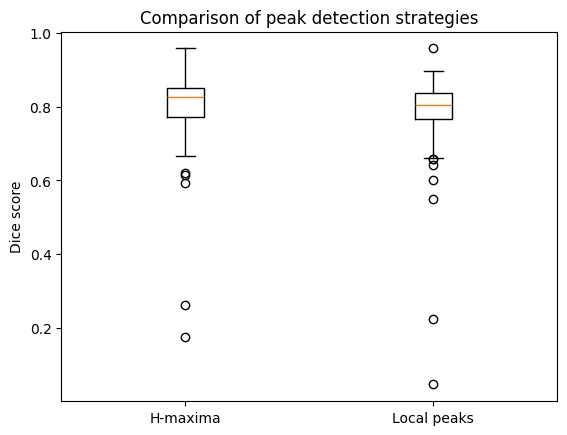

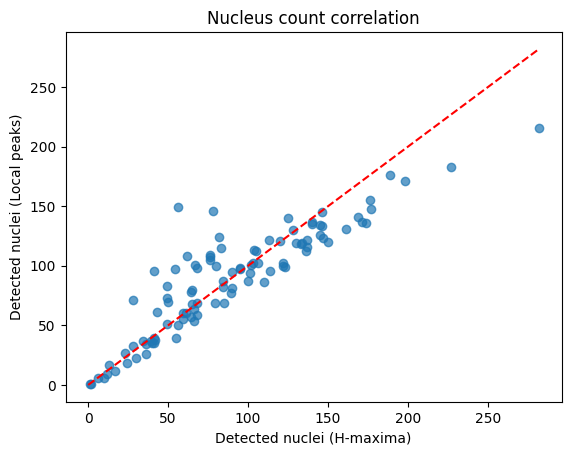

In [19]:
import matplotlib.pyplot as plt

print(df[["dice_hmax", "dice_local"]].mean())

plt.boxplot([df["dice_hmax"], df["dice_local"]],
            labels=["H-maxima","Local peaks"])
plt.ylabel("Dice score")
plt.title("Comparison of peak detection strategies")
plt.show()

plt.scatter(df["count_hmax"], df["count_local"], alpha=0.7)
plt.xlabel("Detected nuclei (H-maxima)")
plt.ylabel("Detected nuclei (Local peaks)")
plt.title("Nucleus count correlation")
plt.plot([0, max(df["count_hmax"].max(), df["count_local"].max())],
         [0, max(df["count_hmax"].max(), df["count_local"].max())], 'r--')
plt.show()


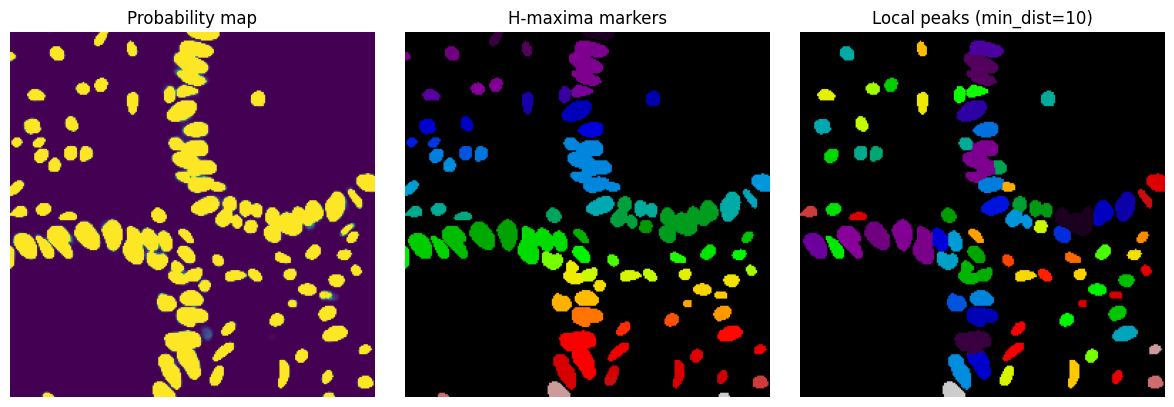

In [20]:
def visualize_example(img_name, min_distance=1):
    img_path = os.path.join(img_dir, img_name)
    gt_path  = os.path.join(gt_dir,  img_name)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    gt  = (cv2.imread(gt_path, 0) > 0).astype(np.uint8)

    with torch.no_grad():
        x = to_tensor(img)
        prob_resized = torch.sigmoid(model(x))[0,0].cpu().numpy()
    prob_map = cv2.resize(prob_resized, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)

    mask, thr = binarize(prob_map, mode="otsu")
    dist = distance_transform_edt(mask)

    # H-maxima
    h_mask    = h_maxima(dist, h=0.3 * (dist.max() if dist.max()>0 else 1.0))
    h_markers = label(h_mask)
    h_labels  = watershed(-dist, markers=h_markers, mask=mask)

    # Local peaks (parametrisierbar)
    coords = peak_local_max(dist, labels=mask, footprint=np.ones((10,10)), min_distance=min_distance)
    lp_markers = np.zeros_like(dist, dtype=np.int32)
    if len(coords) > 0:
        lp_markers[tuple(coords.T)] = np.arange(1, len(coords)+1)
    lp_labels = watershed(-dist, markers=lp_markers, mask=mask)

    # Plot
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1,3, figsize=(12,4))
    axes[0].imshow(prob_map, cmap="viridis"); axes[0].set_title("Probability map"); axes[0].axis("off")
    axes[1].imshow(h_labels, cmap="nipy_spectral"); axes[1].set_title("H-maxima markers"); axes[1].axis("off")
    axes[2].imshow(lp_labels, cmap="nipy_spectral"); axes[2].set_title(f"Local peaks (min_dist={min_distance})"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

# Beispiel:
visualize_example("img_2984.png", min_distance=10)


About Page

In [ ]:
# Block 4

import gradio as gr

def about_page():
    return gr.Markdown(
        """
        # About the Cell Segmentor Dashboard
        The **Cell Segmentor Dashboard** is a powerful tool developed for the segmentation of cell nuclei from microscopy images. It leverages a U-Net++ architecture for precise detection and separation of individual nuclei, making it especially useful for researchers in cellular biology.

        ### Model and Dataset
        - **Model Architecture**: The dashboard uses a U-Net++ model, a deep convolutional neural network designed for image segmentation tasks. U-Net++ improves on traditional U-Net by adding nested convolutions and skip connections, enabling better segmentation accuracy, particularly for complex and overlapping cell structures.
        - **Training Dataset**: The model was trained on the **Data Science Bowl 2018** dataset, which contains a diverse collection of cell images. The dataset was preprocessed to enhance contrast and resize images, making them suitable for the segmentation tasks in this application.

        ### Training and Performance
        - **Training Process**: The model was trained using a combination of Binary Cross-Entropy and Dice loss, optimized with Focal Loss to handle class imbalances. Training used a cyclic learning rate schedule to achieve high accuracy.
        - **Evaluation Metrics**: Model performance is measured using the Dice coefficient and Intersection over Union (IoU) metrics. After training, the model achieved:
          - **Mean Dice Score**: 0.8666
          - **Mean IoU Score**: 0.7727
        - **Early Stopping**: To prevent overfitting, early stopping was applied based on the Dice score.

        ### Key Functionalities
        - **Automated Segmentation**: Upload a microscopy image, and the model will automatically segment the cell nuclei. It employs watershed and distance transform techniques to refine segmentation and separate overlapping nuclei.
        - **Visualization**: View the segmentation mask with individual nuclei labeled, allowing for easy identification and selection.
        - **Property Analysis**: For each segmented nucleus, detailed properties are calculated, including area, perimeter, eccentricity, and solidity. This information helps in quantitative morphological analysis of the nuclei.
        - **Manual Drawing Tool**: Users can also draw custom shapes on an image for a more focused analysis of specific areas. Shape properties are calculated for each custom region.

        ### How to Use
        - **Upload an Image**: Navigate to the **Segment Cells** tab to upload a microscopy image. The tool will then process the image and display the refined segmentation results.
        - **Interactive Nucleus Selection**: Each nucleus is labeled, and users can select individual nuclei to view their properties.
        - **Manual Drawing**: Use the **Draw and Calculate Shape Properties** tab to upload an image and manually draw shapes for custom analysis.

        ### Evaluation Example
        Below is an example of the training and validation performance plot showing both the loss and Dice coefficient over epochs. This demonstrates how the model's accuracy improved over time.

        ![Training and Validation Loss and Dice Coefficient](https://raw.githubusercontent.com/desstaw/CellSeg/refs/heads/main/train_val.png)

        ### Acknowledgments
        This project was developed using open-source libraries like PyTorch, Torchvision, and Albumentations, alongside data provided by the Data Science Bowl. Special thanks to the open-source community and contributors to these libraries, making tools like this possible for advancing cell biology research.
        """
    )

# Create the about page layout
about_interface = gr.Interface(
    fn=about_page,
    inputs=[],
    outputs="markdown",
    title="Cell Segmentor Dashboard - About"
)

about_interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://563e0d60738ab234f7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Combine pages into a tabbed interface

In [ ]:
# Block 5

# Define the combined Gradio tabbed interface
dashboard = gr.TabbedInterface(
    [home_interface, app_interface, about_interface],
    ["Home", "Application", "About"]
)

# Launch the complete dashboard
dashboard.launch(share=True)


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://d5b483295c4c8d0c15.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
